In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# TREBL vs Sort Seq interemdiates

In [63]:
sort_seq = pd.read_csv("../../data/Table_S5_Tile_Activities_Properties_Dataframe.csv")
sort_seq

,ADseq,Name,ArrayDNA,Activity_BioRepA_BYS4,Activity_BioRepB_BYS4,TotalReads_BioRepA_BYS4,TotalReads_BioRepB_BYS4,BioRep_A_GFP_TotalReads,BioRep_A_GFP,BioRep_B_GFP_TotalReads,...,FD,F.D,F..D,MF.Y..L,M..Y..L,SP,[WFYL]...[WFYL][WFYL],WFL,WFYLM,WF
0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_1,ATGGCTTTGAGAATTGAAGTTTATAATAGAATTGAATCTTCTACTG...,62100.52941,39598.983660,1098.0,2857.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,4,7,1
1,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_6,GAAGTTTATAATAGAATTGAATCTTCTACTGCTTCTACTGCTTTGC...,NaN,22153.464390,NaN,43534.0,NaN,NaN,1246.0,...,0,0,0,0,0,0,0,3,6,1
2,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_11,ATTGAATCTTCTACTGCTTCTACTGCTTTGCAAAGACAAGATTTGA...,35362.04714,16461.733700,90903.0,3102.0,1797.0,530.633638,NaN,...,0,0,0,0,0,0,0,4,6,2
3,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_16,GCTTCTACTGCTTTGCAAAGACAAGATTTGAGATATACATTTAGAT...,34961.67558,9931.871718,204600.0,226.0,3974.0,709.844542,NaN,...,0,0,0,0,0,0,0,5,7,2
4,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g_21,CAAAGACAAGATTTGAGATATACATTTAGATCTAATGCTAGAGCTG...,55288.44757,47714.348850,1128.0,43923.0,NaN,NaN,906.0,...,0,0,0,0,0,0,0,5,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20726,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,Gnc4Lib_Kappa_HIGH_0,GCTAAAGTTGATACTGAAGAAGAAGATAAGACTATGGTTGATTCTA...,261745.69420,261913.809000,22275.0,53393.0,2685.0,8782.000000,5662.0,...,1,0,0,0,0,0,0,6,8,3
20727,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,Gnc4Lib_Disorder_HIGH_0,TCTACTGATTATACTCCAATGTTTGAATATGAAACTTATGAAGATA...,261606.12160,261215.289100,3225.0,23456.0,414.0,8782.000000,2446.0,...,1,0,1,0,0,0,0,6,10,4
20728,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,Gnc4Lib_Disorder_HIGH_0,ATGACTGATTCTACTCCAATGTTTGAATATGAATTGACTGAGAATA...,158954.04640,146643.694200,64713.0,46036.0,10295.0,4506.455793,8034.0,...,1,0,1,0,0,0,0,6,9,3
20729,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,Gnc4Lib_Charge_HIGH_0,TCTACTGATTCTACTCCAATGTTTGAATATCAGAATTTGGAGAATA...,120532.32180,105862.794800,4430.0,53110.0,452.0,3363.151895,7755.0,...,1,0,1,1,1,0,0,6,8,3


In [64]:
sort_seq.columns

Index(['ADseq', 'Name', 'ArrayDNA', 'Activity_BioRepA_BYS4',
       'Activity_BioRepB_BYS4', 'TotalReads_BioRepA_BYS4',
       'TotalReads_BioRepB_BYS4', 'BioRep_A_GFP_TotalReads', 'BioRep_A_GFP',
       'BioRep_B_GFP_TotalReads', 'BioRep_B_GFP',
       'BioRep_A_mCherry_TotalReads', 'BioRep_A_mCherry',
       'BioRep_B_mCherry_TotalReads', 'BioRep_B_mCherry',
       'Activity_BYS4_BioRepAverage', 'Stdev_BYS4_BioReps',
       'Activity_SCglucose', 'Start', 'Recovered', 'Charge',
       'HydrophobicityKD', 'HydrophobicityWW', 'Kappa', 'Omega', 'OmegaWFY_DE',
       'OmegaWFYL_DE', 'OmegaWF_D', 'Disorder', 'A', 'C', 'D', 'E', 'F', 'G',
       'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y',
       'Aromatics', 'WFYL', 'W..LF', '[WFYL]..[WFYL][WFYL]',
       '[WFL]..[WFL][WFL]', '[DE][WFY]', '[DE][WF]', '[DE][L]', '[DE].[WFY]',
       '[DE]..[WFY]', 'FF', 'F.F', 'F..F', '[FY].....[FY]DF', 'D.F', 'D..F',
       'FD', 'F.D', 'F..D', 'MF.Y..L', 'M..Y..L', 'SP',
       '[

In [80]:
trebl = pd.read_csv("../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_and_no_CIs.csv", index_col = 0)
trebl = trebl[trebl["time"] == 30]
trebl

,ADseq,time,mean,ci_low,ci_hi,n_barcodes
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2
11,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,30,-0.625492,-1.218028,0.074421,3
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2
25,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,30,2.291359,2.077159,2.472838,2
32,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,30,1.729031,1.603032,1.858250,3
...,...,...,...,...,...,...
50146,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,30,1.399895,NaN,NaN,1
50153,YVIRLSGYMFFGTIASVEKFVRELLSEDSFSRQPIRFLIL,30,-0.461200,NaN,NaN,1
50160,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,30,1.346865,NaN,NaN,1
50167,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,30,1.696234,NaN,NaN,1


In [81]:
trebl_sort_seq_comparison = pd.merge(trebl[["ADseq", "mean"]], sort_seq[["ADseq", "BioRep_A_mCherry", "BioRep_A_GFP", "Activity_BioRepA_BYS4"]])
trebl_sort_seq_comparison = trebl_sort_seq_comparison.rename(columns = {"mean" : "TREBL Log10(Activity)",
                                                                        "BioRep_A_mCherry" : "Sort-Seq mCherry",
                                                                        "BioRep_A_GFP" : "Sort-Seq GFP",
                                                                        "Activity_BioRepA_BYS4" : "Sort-Seq GFP/mCherry"})
trebl_sort_seq_comparison

,ADseq,TREBL Log10(Activity),Sort-Seq mCherry,Sort-Seq GFP,Sort-Seq GFP/mCherry
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0.469307,891.807626,2261.913740,67925.41626
1,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,-0.625492,NaN,NaN,NaN
2,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.813740,1439.467875,2910.521919,58545.82731
3,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.291359,NaN,NaN,NaN
4,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.729031,2637.812261,3588.047696,57441.59958
...,...,...,...,...,...
11089,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.399895,1215.562198,3194.555875,79240.49029
11090,YVIRLSGYMFFGTIASVEKFVRELLSEDSFSRQPIRFLIL,-0.461200,NaN,NaN,NaN
11091,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,1.346865,NaN,NaN,6138.00000
11092,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,1.696234,NaN,NaN,NaN


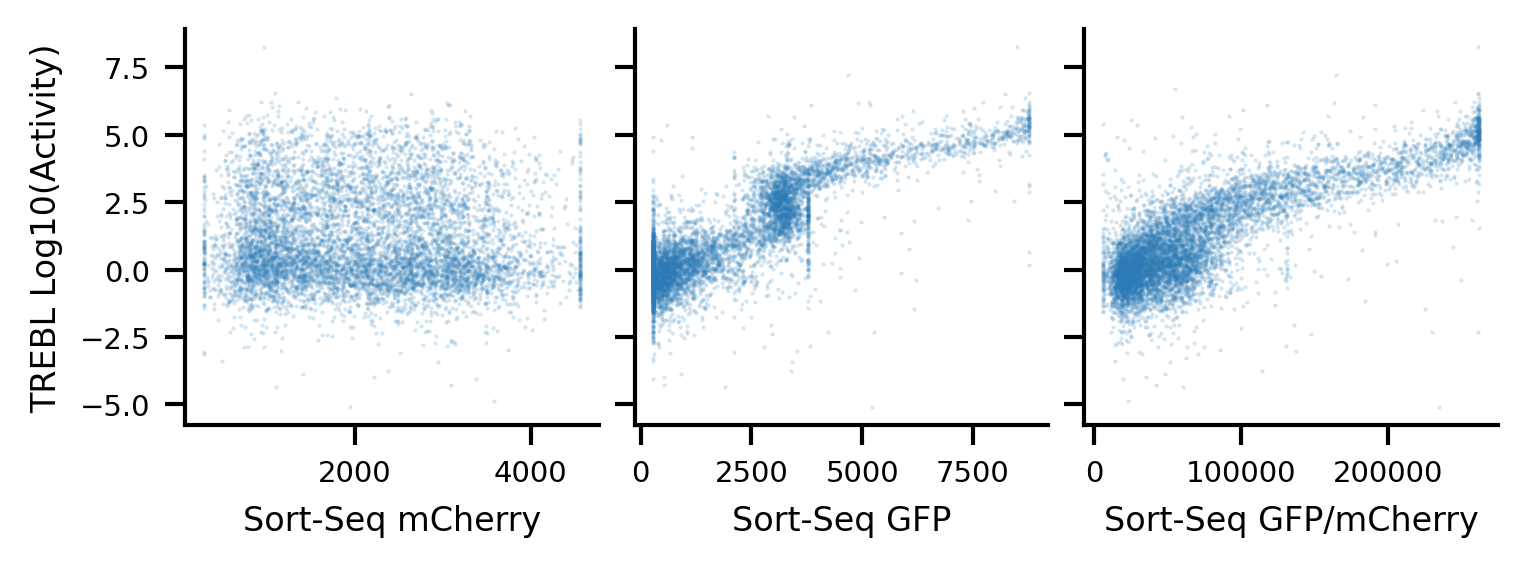

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper', font_scale=1.0)

xcols = [
    "Sort-Seq mCherry",
    "Sort-Seq GFP",
    "Sort-Seq GFP/mCherry"
]

ycol = "TREBL Log10(Activity)"

fig, axes = plt.subplots(
    1, len(xcols),
    figsize=(5, 1.8),
    dpi=300,
    sharey=True
)

for ax, xcol in zip(axes, xcols):

    ok = trebl_sort_seq_comparison[[xcol, ycol]].dropna()

    x = ok[xcol].values
    y = ok[ycol].values


    ax.scatter(
        x, y,
        s=1,
        alpha=0.2,
        linewidths=0,
        color="#2c7bb6"
    )

    ax.set_xlabel(xcol, fontsize=8)
    ax.tick_params(labelsize=7)



axes[0].set_ylabel(ycol, fontsize=8)

sns.despine(fig=fig)

fig.align_ylabels()
fig.tight_layout(pad=0.4)

plt.savefig('../../output/paper_figs/1_GCN4_trebl_vs_sortseq.png',
            dpi=300, bbox_inches='tight')
plt.savefig('../../output/paper_figs/1_GCN4_trebl_vs_sortseq.pdf',
            bbox_inches='tight')

plt.show()

# TREBL vs Sort Seq variance

In [93]:
sort_seq_error = sort_seq[["ADseq", "Activity_BYS4_BioRepAverage", "Stdev_BYS4_BioReps"]].rename(columns = {"Activity_BYS4_BioRepAverage" : "SortSeq_Activity", 
                                                                                           "Stdev_BYS4_BioReps" : "SortSeq_Stdev"})
sort_seq_error

,ADseq,SortSeq_Activity,SortSeq_Stdev
0,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQA,50849.75654,15910.995590
1,EVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQ,NaN,NaN
2,IESSTASTALQRQDLRYTFRSNARAASGQANANYQAFTAG,25911.89042,13364.539800
3,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,22446.77365,17698.744050
4,QRQDLRYTFRSNARAASGQANANYQAFTAGSALNGPSLPA,51501.39821,5355.696567
...,...,...,...
20726,AKVDTEEEDKTMVDSTSLSWEDLFDFESYSTDLIASINPD,261829.75160,118.875127
20727,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,261410.70530,276.360314
20728,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,152798.87030,8704.733507
20729,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,113197.55830,10372.922070


In [94]:
trebl["ci_width"] = trebl["ci_hi"] - trebl["ci_low"]
trebl_error = trebl[["ADseq", "mean", "ci_width"]].rename(columns = {"mean" : "trebl_activity"})
trebl_error

,ADseq,trebl_activity,ci_width
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0.469307,1.444178
11,AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK,-0.625492,1.292449
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.813740,1.062373
25,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.291359,0.395679
32,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.729031,0.255218
...,...,...,...
50146,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.399895,NaN
50153,YVIRLSGYMFFGTIASVEKFVRELLSEDSFSRQPIRFLIL,-0.461200,NaN
50160,YWSHPTLKHTRPNTASVPSNSPNTNRPPIPLFNGQQNHNQ,1.346865,NaN
50167,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,1.696234,NaN


In [97]:
errors_merged = pd.merge(sort_seq_error, trebl_error)
errors_merged = errors_merged.dropna()
errors_merged

,ADseq,SortSeq_Activity,SortSeq_Stdev,trebl_activity,ci_width
2,ASTALQRQDLRYTFRSNARAASGQANANYQAFTAGSALNG,22446.77365,17698.744050,0.706388,1.170053
5,ASGQANANYQAFTAGSALNGPSLPAPSLFAGHGPEAHSDH,31637.98609,2805.086924,1.744028,1.316203
6,NANYQAFTAGSALNGPSLPAPSLFAGHGPEAHSDHSAQRG,35182.01274,8572.158229,0.143288,0.360439
7,SALNGPSLPAPSLFAGHGPEAHSDHSAQRGIRLSGLEARE,41694.07499,7052.447512,0.112412,0.566136
12,PASSRIEVASWAHEFQRLAPNIAATGPAIAPSQAPAIGGP,78202.80875,47862.688880,0.318153,0.267488
...,...,...,...,...,...
11084,STDSTPMFDYDNLEDNSKDWTSLFDNDIPVTTDDVSLADK,166175.36020,32.437321,3.701892,1.010902
11090,STDYTPMFEYETYEDNFKEWTSLFDNDIPVTTDDVSLADR,261410.70530,276.360314,2.855826,7.679921
11091,MTDSTPMFEYELTENNSKEWTSLFDTDIPVTTDDESLADK,152798.87030,8704.733507,4.053596,0.932383
11092,STDSTPMFEYQNLENNSKEWTSLFDNDIPVTTDNVSLADK,113197.55830,10372.922070,3.110095,0.948556


In [98]:
df = errors_merged
df["sortseq_cv"] = df["SortSeq_Stdev"] / df["SortSeq_Activity"]
df["trebl_relative_ci"] = df["ci_width"] / df["trebl_activity"].abs()

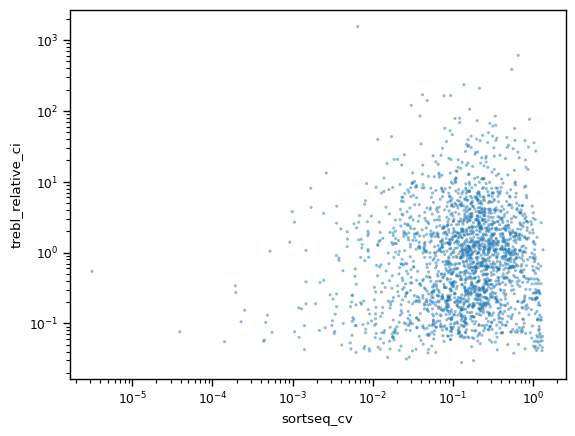

In [105]:
ax = sns.scatterplot(data = df, x = "sortseq_cv", y = "trebl_relative_ci", edgecolor = 'none', alpha = 0.5, s = 5)
ax.set_xscale('log')
ax.set_yscale('log')